In [43]:
#import
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [123]:
#parameters
l1 = 1
l2 = 1
l3 = 0.5

th1 = 0.5
th2 = 0.4
th3 = 0.2

In [124]:
# build linkage
x0 = 0
y0 = 0

x1 = x0 + l1*np.cos(th1)
y1 = y0 + l1*np.sin(th1)

x2 = x1 + l2*np.cos(th2)
y2 = y1 + l2*np.sin(th2)

x3 = x2 + l3*np.cos(th3)
y3 = y2 + l3*np.sin(th3)

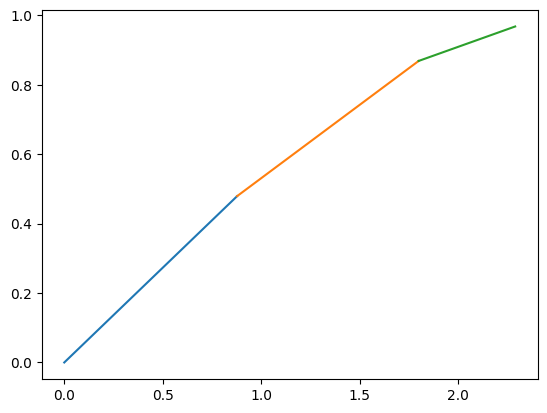

In [125]:
#plot

plt.plot([x0, x1], [y0, y1])
plt.plot([x1, x2], [y1, y2])
plt.plot([x2, x3], [y2, y3])

In [134]:
# calculate the jacobian of kinematics

th_1, th_2, th_3 = sp.symbols('theta_1 theta_2 theta_3')

th = sp.Matrix([th_1, th_2, th_3]).T

x1 = x0 + l1 * sp.cos(th_1)
y1 = y0 + l1 * sp.sin(th_1)
x2 = x1 + l2 * sp.cos(th_2)
y2 = y1 + l2 * sp.sin(th_2)
x3 = x2 + l3 * sp.cos(th_3)
y3 = y2 + l3 * sp.sin(th_3)

f = sp.Matrix([x0, y0, x1, y1, x2, y2, x3, y3])

f1 = sp.Matrix([x1])

df1dx = sp.diff(x0, th)
df2dx = sp.diff(y0, th)
df3dx = sp.diff(x1, th)
df4dx = sp.diff(y1, th)
df5dx = sp.diff(x2, th)
df6dx = sp.diff(y2, th)
df7dx = sp.diff(x3, th)
df8dx = sp.diff(y3, th)


#dfdx = sp.Matrix([df1dx, df2dx, df3dx, df4dx, df5dx, df6dx, df7dx, df8dx])

dfdx = sp.Matrix([df7dx, df8dx])
dfdx

Matrix([
[-sin(theta_1), -sin(theta_2), -0.5*sin(theta_3)],
[ cos(theta_1),  cos(theta_2),  0.5*cos(theta_3)]])

In [127]:
# solve the jacobian at current theta
th1_0 = 0.5
th2_0 = 0.5
th3_0 = 0.3

dfdx_eval = dfdx.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0})
dfdx_eval

Matrix([
[-0.479425538604203, -0.479425538604203, -0.14776010333067],
[ 0.877582561890373,  0.877582561890373, 0.477668244562803]])

In [128]:
#inverse jacobian
dfdx_eval.pinv()

Matrix([
[-2.40433811626187, -0.74374893567791],
[-2.40433811626187, -0.74374893567791],
[ 8.83460530498942,  4.82636687490288]])

In [150]:
# prime loop
th1_0 = 0.5
th2_0 = 0.5
th3_0 = 0.3

th0 = sp.Matrix([th1_0, th2_0, th3_0])
th = th0

dfdx_eval = dfdx.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0})

x_d = sp.Matrix([2, 0])
x_a = sp.Matrix([x3.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0}), y3.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0})])
e = x_d - x_a
print("error: ", e.norm())

th = th + dfdx_eval.pinv() @ e
print(th[0])
print(th[1])
print(th[2])

error:  1.13084025499108
1.88285102998125
1.88285102998125
-7.09790245629744


In [152]:
#run loop
while(e.norm() > .1):
    th1 = th[0]
    th2 = th[1]
    th3 = th[2]

    dfdx_eval = dfdx.subs({th_1: th1, th_2:th2, th_3:th3})

    x_d = sp.Matrix([2, 0])
    x_a = sp.Matrix([x3.subs({th_1: th1, th_2:th2, th_3:th3}), y3.subs({th_1: th1, th_2:th2, th_3:th3})])
    e = x_d - x_a
    print("error: ", e.norm())

    th = th + dfdx_eval.pinv() @ e
    

In [179]:
def findIK(th1_0, th2_0, th3_0, x_d, y_d):
    th_1, th_2, th_3 = sp.symbols('theta_1 theta_2 theta_3')
    th = sp.Matrix([th_1, th_2, th_3]).T
    
    x0 = 0
    y0 = 0
    x1 = x0 + l1 * sp.cos(th_1)
    y1 = y0 + l1 * sp.sin(th_1)
    x2 = x1 + l2 * sp.cos(th_2)
    y2 = y1 + l2 * sp.sin(th_2)
    x3 = x2 + l3 * sp.cos(th_3)
    y3 = y2 + l3 * sp.sin(th_3)
    
    f = sp.Matrix([x0, y0, x1, y1, x2, y2, x3, y3])
    
    df1dx = sp.diff(x0, th)
    df2dx = sp.diff(y0, th)
    df3dx = sp.diff(x1, th)
    df4dx = sp.diff(y1, th)
    df5dx = sp.diff(x2, th)
    df6dx = sp.diff(y2, th)
    df7dx = sp.diff(x3, th)
    df8dx = sp.diff(y3, th)

    dfdx = sp.Matrix([df7dx, df8dx])

    

    #make theta vector
    th0 = sp.Matrix([th1_0, th2_0, th3_0])
    th = th0

    #make jacobian
    dfdx_eval = dfdx.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0})

    #make error
    state_d = sp.Matrix([x_d, y_d])
    state_a = sp.Matrix([x3.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0}), y3.subs({th_1: th1_0, th_2:th2_0, th_3:th3_0})])
    e = state_d - state_a
    print("error: ", e.norm())

    #solve 1 step
    th = th + dfdx_eval.pinv() @ e
    
    # run loop
    err = list()
    err.append(e.norm())
    
    while(e.norm() > .1):
        err.append(e.norm())
        
        th1 = th[0]
        th2 = th[1]
        th3 = th[2]
    
        dfdx_eval = dfdx.subs({th_1: th1, th_2:th2, th_3:th3})
    
        state_d = sp.Matrix([x_d, y_d])
        state_a = sp.Matrix([x3.subs({th_1: th1, th_2:th2, th_3:th3}), y3.subs({th_1: th1, th_2:th2, th_3:th3})])
        e = state_d - state_a
        err.append(e.norm())
        print("error: ", e.norm())
    
        th = th + dfdx_eval.pinv() @ e
    return th, err

In [170]:
# compute forward kinematics

def FK_from_theta(th1, th2, th3):
    
    x0 = 0
    y0 = 0
    x1 = x0_0 + l1 * sp.cos(th1)
    y1 = y0_0 + l1 * sp.sin(th1)
    x2 = x1_0 + l2 * sp.cos(th2)
    y2 = y1_0 + l2 * sp.sin(th2)
    x3 = x2_0 + l3 * sp.cos(th3)
    y3 = y2_0 + l3 * sp.sin(th3)
    
    return [x0, y0, x1, y1, x2, y2, x3, y3]

error:  1.13084025499108
error:  2.74370357488565
error:  1.97083903524225
error:  3.15072902495160
error:  0.890870022147893
error:  1.88669452266637
error:  0.588160849694077
error:  0.687597774355032
error:  0.177670006712468
error:  0.00782505724448007
-0.250656549222287 -0.250656549222287 -4.83769043693813


Text(0, 0.5, 'Final')

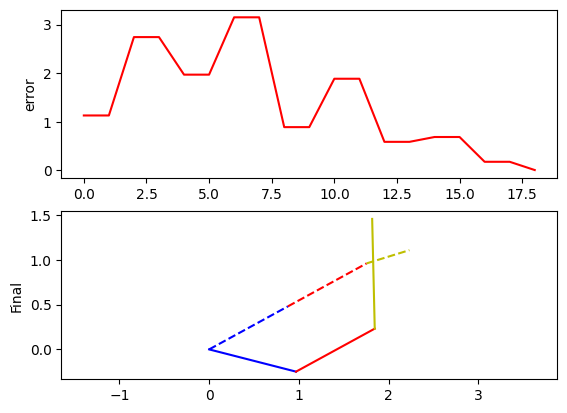

In [183]:
#graph final result
th1_0 = 0.5
th2_0 = 0.5
th3_0 = 0.3

x0_0, y0_0, x1_0, y1_0, x2_0, y2_0, x3_0, y3_0 = FK_from_theta(th1_0, th2_0, th3_0)

th, err = findIK(th1_0, th2_0, th3_0, 2, 0)

th1_f = th[0]
th2_f = th[1]
th3_f = th[2]
print(th1_f, th2_f, th3_f)

x0, y0, x1, y1, x2, y2, x3, y3 = FK_from_theta(th1_f, th2_f, th3_f)

plt.subplot(2,1,1)
plt.plot(err, 'r')
plt.ylabel('error')

plt.subplot(2,1,2)
plt.plot([x0_0, x1_0], [y0_0, y1_0], 'b--')
plt.plot([x1_0, x2_0], [y1_0, y2_0], 'r--')
plt.plot([x2_0, x3_0], [y2_0, y3_0], 'y--')

plt.plot([x0, x1], [y0, y1], 'b')
plt.plot([x1, x2], [y1, y2], 'r')
plt.plot([x2, x3], [y2, y3], 'y')
plt.axis('equal')
plt.ylabel('Final')